# Aufgabe 5 – MNIST / fashion-MNIST

## 5a) Daten importieren und präparieren

Wir importieren den Datensatz mit den handgeschriebenen Ziffern. Die Daten sind in einer 28x28 Matrix mit einem Wert von 0 bis 255.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.datasets import mnist  # oder fashion_mnist
import seaborn as sns
from sklearn.metrics import confusion_matrix



(feature_train, labels_train), (feature_test, labels_test) = mnist.load_data() # Laden der Daten

feature_train = feature_train[:10000] # Nur die ersten 10000 Bilder
labels_train = labels_train[:10000]
feature_test = feature_test[:10000]
labels_test = labels_test[:10000]

feature_train = feature_train / 255.0 # Damit die Pixelwerte zwischen 0 und 1 liegen
feature_test = feature_test / 255.0

#index = np.random.randint(0, len(feature_train))
#plt.imshow(feature_train[index], cmap='gray')
#plt.title(f"Label: {labels_train[index]}")
#plt.show()

I0000 00:00:1785146574.622733     821 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785146574.690267     821 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785146576.303514     821 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 5b) Netz mit nur einem Output-Layer

Es wird ein Neuronales Netz mit einem Output-Layer generiert.

In [2]:
NN = Sequential()
NN.add(Flatten(input_shape=(28, 28)))
NN.add(Dense(10, activation="softmax")) #10 Neuronen
#NN.summary()

/var/data/python/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1785146578.355894     821 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 5c) Kompilieren, trainieren, evaluieren

Dieses Neuronale Netz wird nun trainiert. Hierfür wird das Netz für je 5 Epochen trainiert und der Mittelwert der Accuracy über 10 Durchläufe gemittelt. Mit diesem Ansatz soll die statistische Schwankungen, welche durch die zufällig gewählten Startvariablen verursacht wird, reduziert werden.

Parameter: 5 Epochen, 10 Durchläufe, 10000 Trainings- & Testdatenpunkte
Mittelwert (der val_accuracy): (0.9083+0.9133+0.9158+0.9164+0.9137+0.9155+0.9142+0.9144+0.9132+0.9144+0.9129)/10 = 0.91366

In [3]:
NN.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
NN.fit(feature_train, labels_train, epochs=5, validation_data=(feature_test, labels_test))

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7829 - loss: 0.8881 - val_accuracy: 0.8728 - val_loss: 0.5166
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8901 - loss: 0.4403 - val_accuracy: 0.8959 - val_loss: 0.4029
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9045 - loss: 0.3650 - val_accuracy: 0.9037 - val_loss: 0.3654
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9116 - loss: 0.3283 - val_accuracy: 0.9054 - val_loss: 0.3437
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9175 - loss: 0.3039 - val_accuracy: 0.9100 - val_loss: 0.3277


## 5d) Confusion Matrix

Es wird eine Confusion Matrix erzeugt, welche die verwechselten Zahlen in einem anschaulichen Bild sichtbar macht.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step


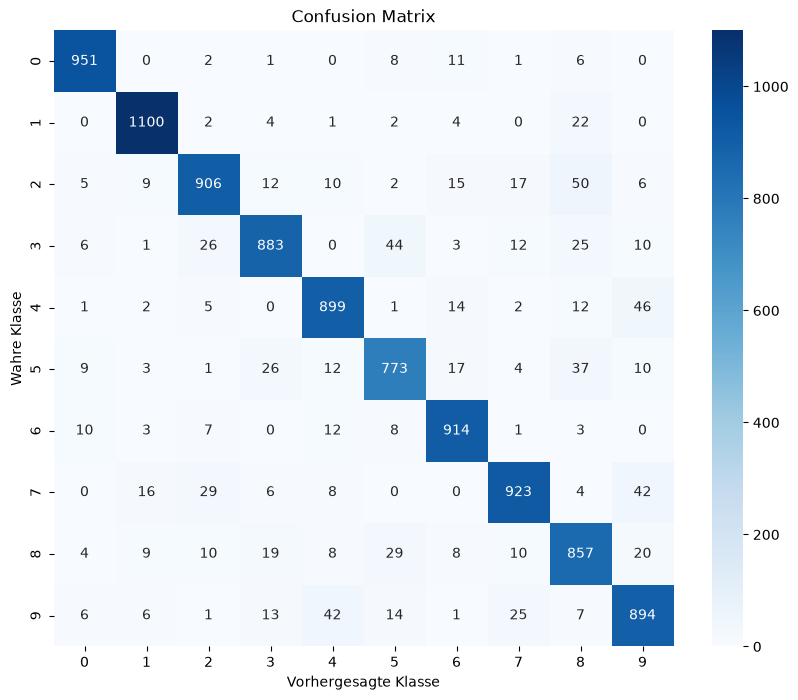

In [4]:
feature_test_predictions_probability = NN.predict(feature_test) # Wahrscheinlichkeiten für jede Klasse
labels_test_predictions = np.argmax(feature_test_predictions_probability, axis=1) # Höchste Wahrscheinlichkeit

confmatrix = confusion_matrix(labels_test, labels_test_predictions)

plt.figure(figsize=(10, 8)) 
sns.heatmap(confmatrix, annot=True, fmt="d", cmap="Blues") # annot = Zahlen in den Zellen, fmt = Formatierung der Zahlen, cmap = Farbskala
plt.xlabel("Vorhergesagte Klasse") # Achse
plt.ylabel("Wahre Klasse") # Achse
plt.title("Confusion Matrix") # Titel
plt.show()

Die höchsten Werte der falsch erkannten Zahlen betragen je nach Durchlauf ungefähr 50 bis 60.

## 5e) Hidden-Layer ergänzen und vergleichen

Das Neuronale Netz wird mit einem Hidden-Layer erweitert und anschließend mit einer unterschiedlichen Anzahl an Neuronen getestet. Es werden die gleichen Parameter, wie beim Trainieren des Neuronales Netzes ohne Hidden-Layer verwendet; Mittelung über 5 Epochen, 10 Durchläufe, 10000 Datenpunkte.

In [ ]:
def NN2(Anzahl):
    NN = Sequential()
    NN.add(Flatten(input_shape=(28, 28)))
    NN.add(Dense(Anzahl, activation="relu")) # Hidden-Layer
    NN.add(Dense(10, activation="softmax")) # 10 Neuronen im letzten Layer
    NN.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    NN.fit(feature_train, labels_train, epochs=5, validation_data=(feature_test, labels_test), verbose=1)
    accuracy = NN.evaluate(feature_test, labels_test)
    return accuracy[1], NN

ergebnisse = []
for i in range(10):
    print(f"Simulation {i+1}/10 läuft...")
    accuracy, NN3 = NN2(100) # Anzahl der Neuronen im Hidden-Layer
    ergebnisse.append(accuracy)

gesamt_mittelwert = np.mean(ergebnisse)

print(f"\nDurchschnittliche Test-Accuracy aus 10 Durchläufen: {gesamt_mittelwert:.4f}") # Ausgabe der gemittelten Accuracy


# Der Durchlauf über die verschiedenen Anzahlen von Neuronen im Hidden-Layer lässt sich hiermit automatisieren
#neuronen_liste = [10, 20, 50, 100, 250, 500, 1000] 
#tabelle = {}
#for anzahl in neuronen_liste:
#    ergebnisse = []
#    for i in range(10):
#        accuracy, NN3 = NN2(anzahl)
#        ergebnisse.append(accuracy)
#    tabelle[anzahl] = np.mean(ergebnisse)
#    print(f"Neuronen: {anzahl}, gemittelte Accuracy: {tabelle[anzahl]:.4f}")

Simulation 1/10 läuft...
Epoch 1/5


/var/data/python/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8539 - loss: 0.5259 - val_accuracy: 0.9061 - val_loss: 0.3273
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9306 - loss: 0.2511 - val_accuracy: 0.9245 - val_loss: 0.2532
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9469 - loss: 0.1891 - val_accuracy: 0.9343 - val_loss: 0.2202
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9565 - loss: 0.1470 - val_accuracy: 0.9396 - val_loss: 0.2042
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9666 - loss: 0.1185 - val_accuracy: 0.9426 - val_loss: 0.1928
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9426 - loss: 0.1928
Simulation 2/10 läuft...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8565 - loss: 0.5344 - val_accuracy: 0.9135 - val_loss: 0.3029
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9292 - loss: 0.2535 - val_accuracy: 0.9279 - val_loss: 0.2493
Epoch 3/5
313/313 ━━━

Die Testergebnisse lassen sich aus folgender Tabelle entnehmen:

Parameter: 5 Epochen, 10 Durchläufe, 10000 Trainings- & Testdatenpunkte

Anzahl Neuronen

| Anzahl der Neuronen | Gemittelte Accuracy | Delta zum Vorherigem |
| :--- | :--- | :--- |
| 10 | 0.9028 | |
| 20 | 0.9206 | +0.0178, +1.93%  |
| 50 | 0.9310 | +0.0104, +1.12% |
| 100 | 0.9419 | +0.0109, +1.16% |
| 250 | 0.9489 | +0.007, +0.74% |
| 500 | 0.9533 | +0.0044, +0.46% |
| 1000 | 0.9565 | +0.0032, +0.33% |

Zu erkennen ist, dass die Erhöhung der Anzahl der Neuronen die gemittelte Accuracy verbessert. Dieser Zusammenhang ist jedoch nicht proportional; die Verbresserung der gemittelten Accuracy nimmt mit jeder Verdopplung der Anzahl der Neuronen weiter ab. 
Dies lässt sich mit folgendem Graphen visualisieren:

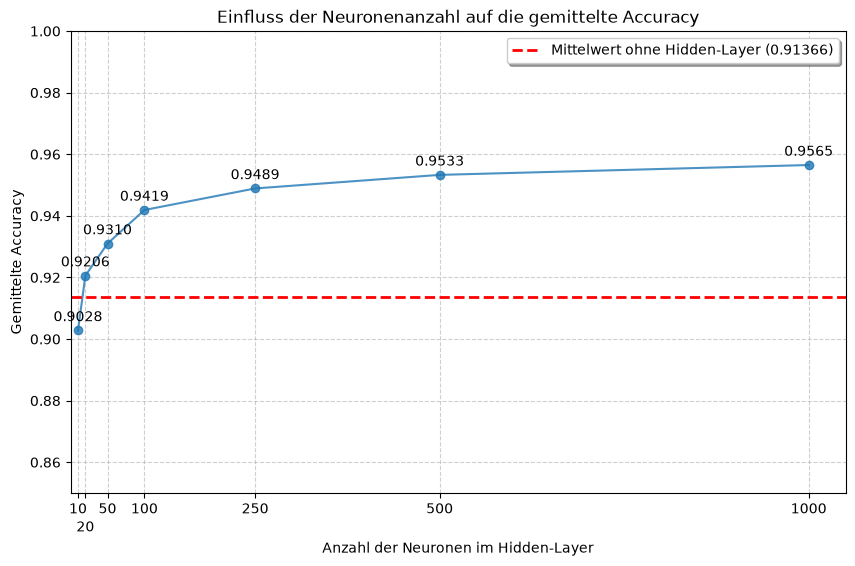

In [6]:
neuronen = [10, 20, 50, 100, 250, 500, 1000]
accuracy = [0.9028, 0.9206, 0.9310, 0.9419, 0.9489, 0.9533, 0.9565]

plt.figure(figsize=(10, 6))

plt.plot(neuronen, accuracy, marker="o", alpha = 0.8)

for x, y in zip(neuronen, accuracy):
    plt.text(x, y+0.003, f"{y:.4f}", ha="center",)

plt.xlabel("Anzahl der Neuronen im Hidden-Layer")
plt.ylabel("Gemittelte Accuracy")
plt.title("Einfluss der Neuronenanzahl auf die gemittelte Accuracy")

#plt.xscale('log')
plt.xticks(neuronen, labels=["10", "\n20", "50", "100", "250", "500", "1000"])

plt.xlim(0, 1050)
plt.ylim(bottom=0.85, top=1)

plt.grid(True, linestyle='--', alpha=0.6)

plt.axhline(y=0.91366, color='r', linestyle='--', linewidth=2, label='Mittelwert ohne Hidden-Layer (0.91366)')
plt.legend(shadow=True)

plt.show()

Zu beobachten ist, dass ein Neuronales Netz mit einer zusätzlichen Hidden-Layer mit 10 Neuronen schlechter abschneidet, als ein Neuronales Netz mit nur einer direkten Layer mit 10 Neuronen. Dies ändert sich bei der Erhöhung der Epochen.

Nun wird die Confusion Matrix für das Modell mit der zusätzlichen Hidden-Layer ausgegeben. Dies wurde für jede simulierte Anzahl an Neuronen im Hidden-Layer manuell durchgeführt.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step


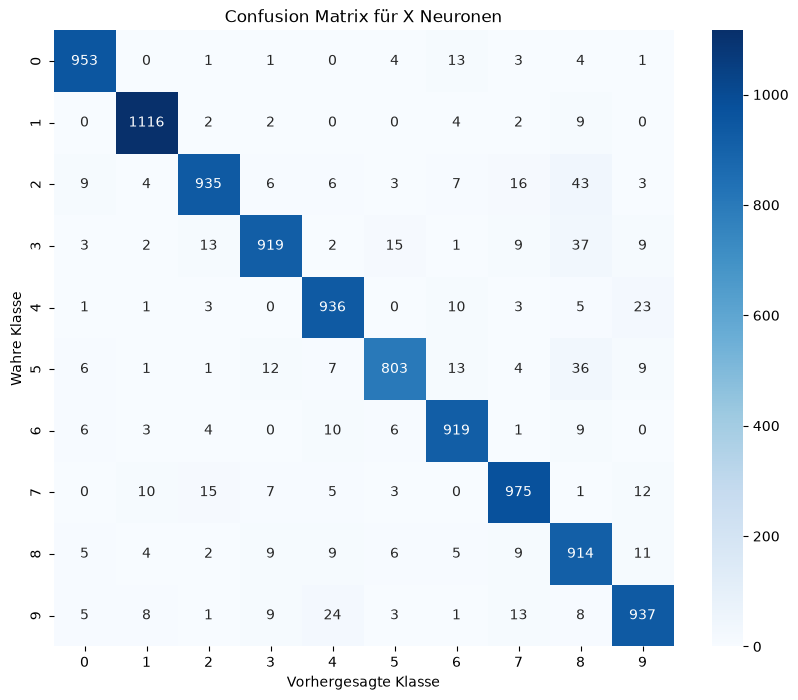

In [7]:
feature_test_predictions_probability = NN3.predict(feature_test) 
labels_test_predictions = np.argmax(feature_test_predictions_probability, axis=1) 

confmatrix = confusion_matrix(labels_test, labels_test_predictions)

plt.figure(figsize=(10, 8)) 
sns.heatmap(confmatrix, annot=True, fmt='d', cmap='Blues') 
plt.xlabel("Vorhergesagte Klasse") 
plt.ylabel("Wahre Klasse") 
plt.title("Confusion Matrix für X Neuronen") 
plt.show()

Alle Confusion Matrizen lassen sich wie folgt ausgeben (vorher generiert und gespeichert):

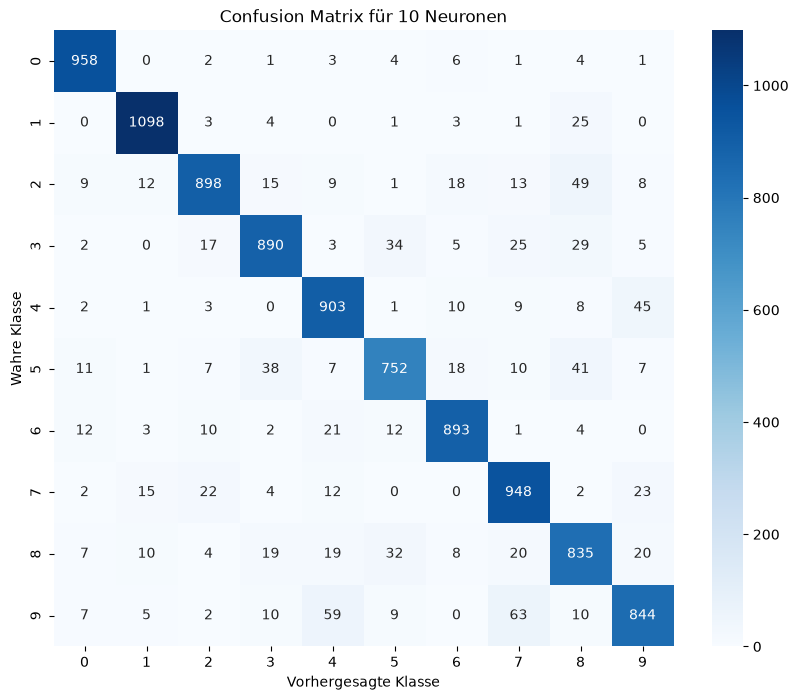

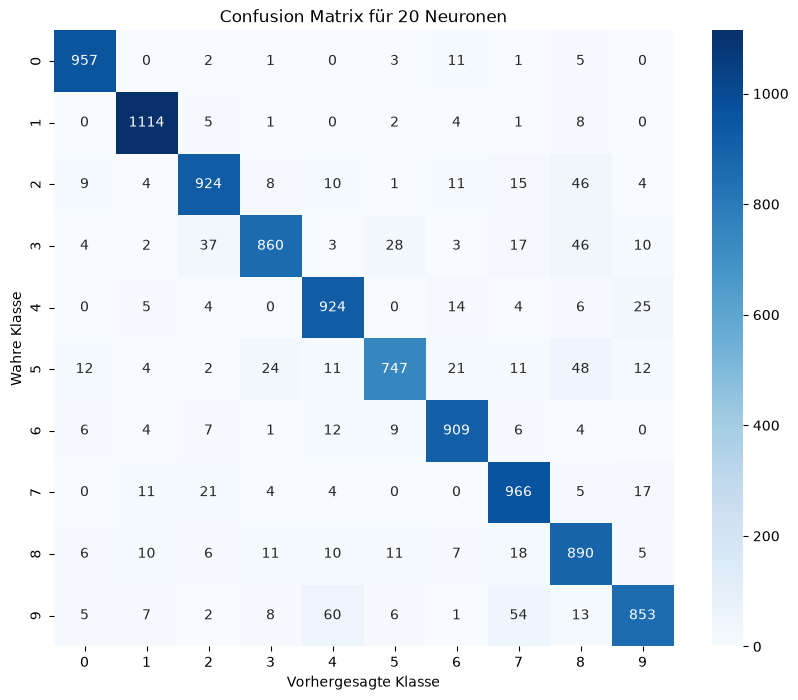

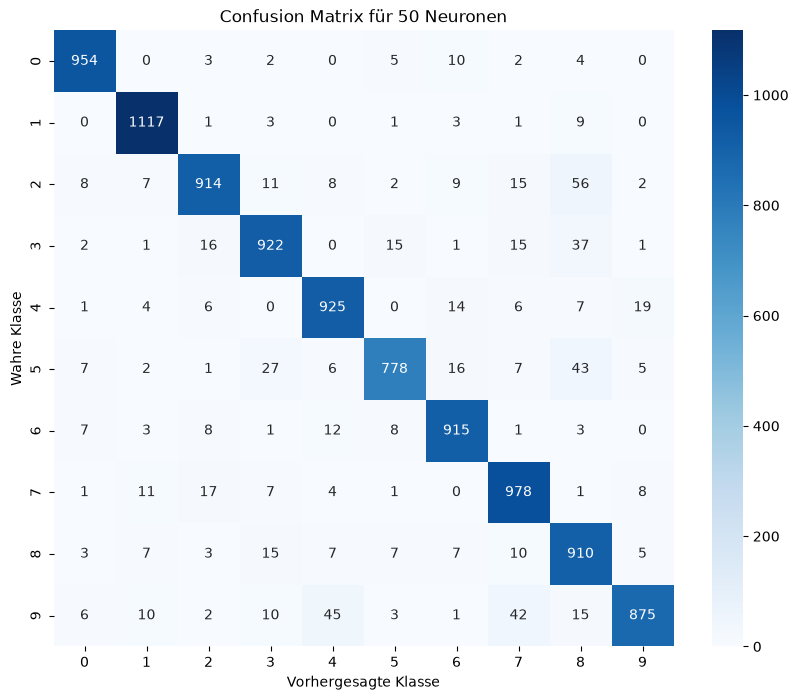

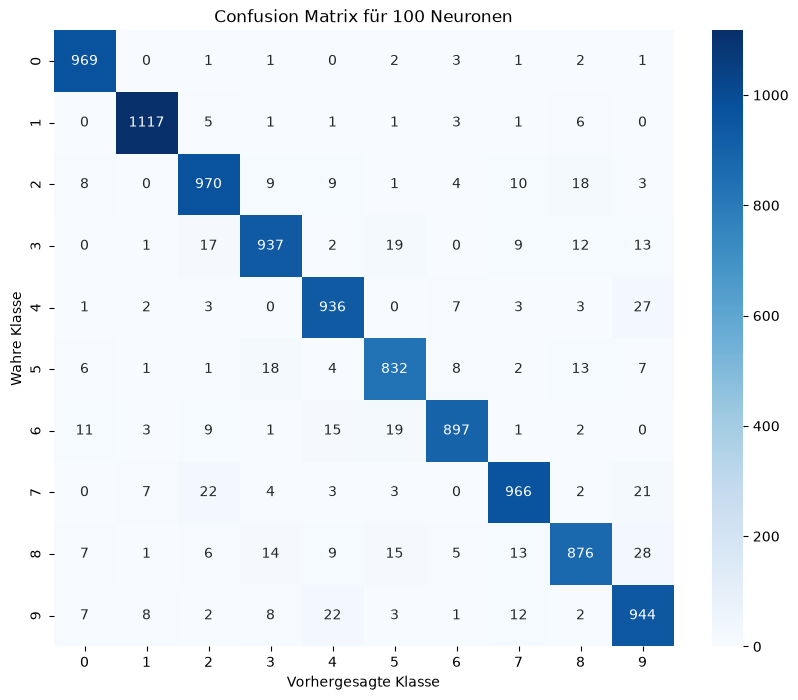

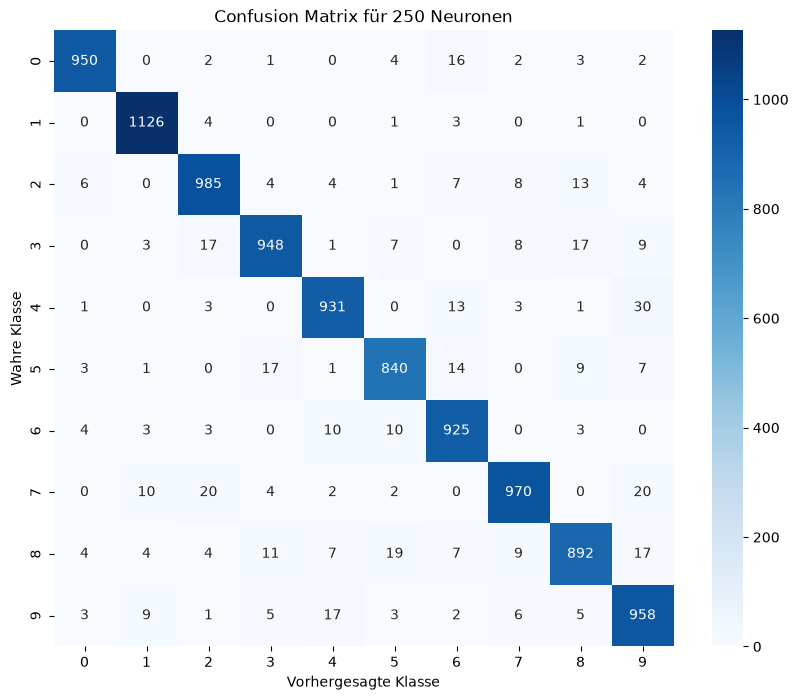

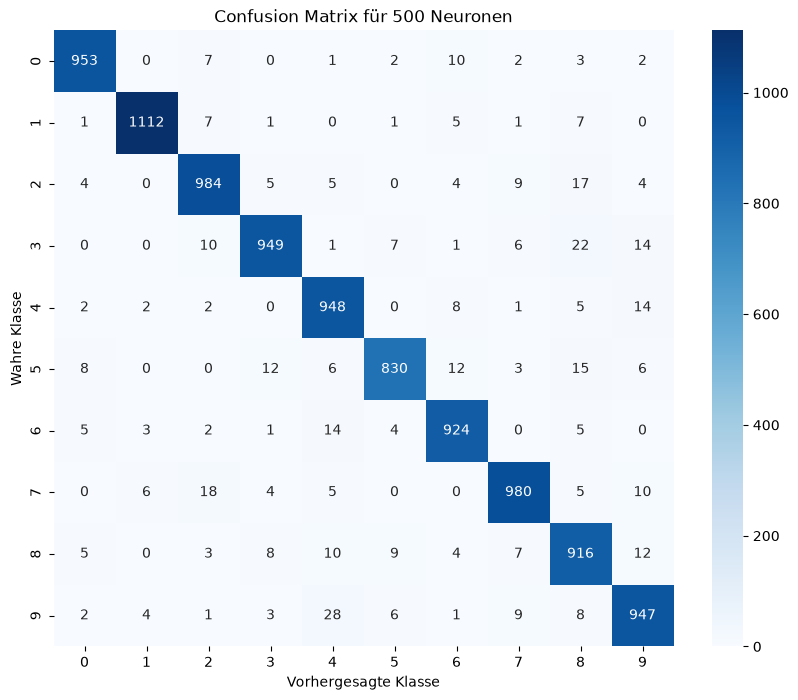

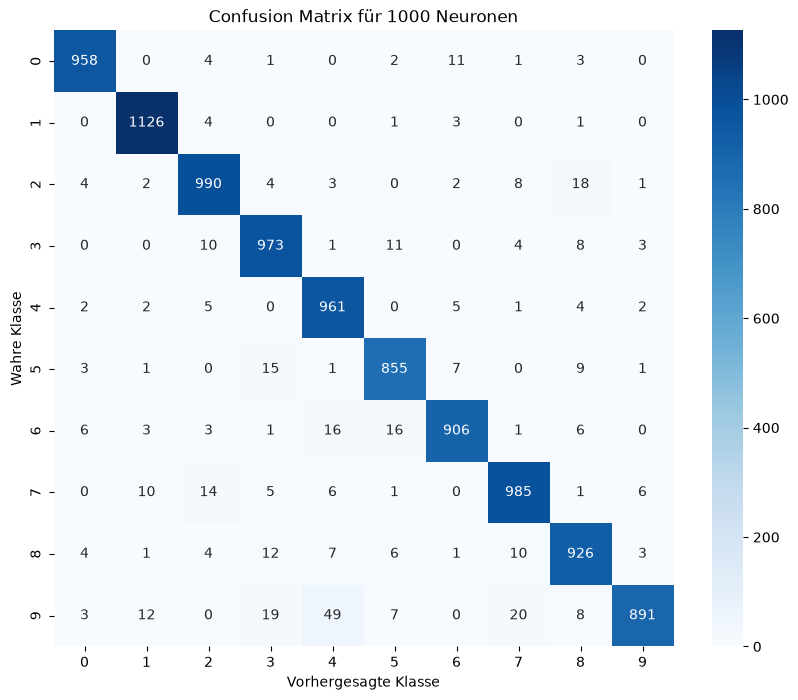

In [8]:
from IPython.display import Image, display
display(Image(filename="images/10.png"))
display(Image(filename="images/20.png"))
display(Image(filename="images/50.png"))
display(Image(filename="images/100.png"))
display(Image(filename="images/250.png"))
display(Image(filename="images/500.png"))
display(Image(filename="images/1000.png"))


Zu erkennen ist, dass die Werte der falsch erkannten Zahlen nehmen mit der Erhöhung der Anzahl der Neuronen im Hidden-Layer ab. Die Anzahl der falsch erkannten Zahlen hat ab 100 Neuronen keine Werte mehr über 50.